# ODI Cricket Match - Score & Win Predictor Modelling
### Using XGBoost on Ball-by-Ball Data (Cricsheet)

This project builds two machine learning models to predict ODI cricket match outcomes 
using ball-by-ball data from [Cricsheet](https://cricsheet.org/):

1. **1st Innings Score Predictor** — A regression model estimating final innings score 
   from in-match state at each over.
2. **2nd Innings Chase Predictor** — A classification model estimating win probability 
   for the chasing team at each over.

Base features simply capture match state - the over, wickets and runs (and required run rate for the 2nd innings model).

Features engineered include in-match momentum indicators, Bayesian venue statistics, 
and Elo ratings tracking team strength over time.

**Tech stack:** Python · Pandas · Scikit-learn · Matplotlib

In [15]:
#import packages
import pandas as pd
import re
import json
from match_class import Match
import time
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [ ]:
#manual data load (~20 mins)

match_type = "odis"

path_to_json = f'C:\\Users\\olive\\OneDrive\\Documents\\Sports Related Coding Practice\\Cricket\\{match_type}_json\\'
filename = f'C:\\Users\\olive\\OneDrive\\Documents\\Sports Related Coding Practice\\Cricket\\{match_type}_list.csv'
match_info_all_df = pd.read_csv(filename)
files_male_only = match_info_all_df[match_info_all_df["Gender"] == "male"]["Filenumber"]
json_files = [path_to_json + k for k in files_male_only]

matches_ingested = 0
time_start = time.perf_counter()
all_matches = {}
for file in json_files:  
    with open(file, 'r') as f:
        match_json = json.load(f)
    match = Match(match_json)
    all_matches[match.match_id] = match
    matches_ingested += 1
    if matches_ingested % 50 == 0:
        time_end = time.perf_counter()
        time_elapsed = round(time_end - time_start,2)
        print(f"{matches_ingested}/{len(json_files)} matches ingested ({time_elapsed}s passed)")

time_end = time.perf_counter()
time_elapsed = round(time_end - time_start,2)
print(f"Time elapsed for ingestion of {matches_ingested} matches: {time_elapsed} seconds")

In [ ]:
#using joblib for quick data reload (~40 sec)
from joblib import load
all_matches = load('C:\\Users\\olive\\OneDrive\\Documents\\Sports Related Coding Practice\\Cricket\\all_odis.joblib')

## Data Preparation

In [4]:
#generating match info dataframe
rows = []
venue_dict = {} # venue : [city,city]
city_exceptions = { #exception : revert to
    "Dharmasala" : "Dharamsala",
    "King City" : "Toronto" ,
    "Chittagong" : "Chattogram",
    "Mirpur" : "Dhaka",
    "Port Elizabeth" : "Gqeberha"
}
for match_id, match in all_matches.items():
    teams = match.match_info.get("teams",{})
    year = int(match.match_info.get("dates")[0][:4])
    team1 = teams[0]
    team2 = teams[1]
    winner = match.match_info.get("outcome").get("winner","NA")

    venue = match.match_info.get("venue","NA")
    city = match.match_info.get("city","NA")
    if city in city_exceptions:
        city = city_exceptions[city]
    if city != "NA":
        venue_dict[venue] = city
        """
        if venue not in venue_dict:
            venue_dict[venue] = city
        else:
            if city != venue_dict[venue]:
                print(f"exception: {venue}: {city} {venue_dict[venue]}")
"""

    set_score = match.total_scores.get(1,np.nan)
    chase_score = match.total_scores.get(2,np.nan)
    try:
        win_type = list(match.match_info.get("outcome",{}).get("by",{}).keys())[0]
        if win_type == "runs":
            winner_type = 0
            winning_score = set_score
        elif win_type == "wickets":
            winner_type = 1
            winning_score = np.nan
    except: 
        winner_type = np.nan
        winning_score = np.nan

    rows.append((match_id, year, team1, team2, winner, venue, city, set_score, chase_score, winner_type*100, winning_score))
match_info_df = pd.DataFrame(rows, columns=["Match ID", "Year", "Team 1", "Team 2", "Winner", "Venue", "City", "Set Score", "Chase Score", "Chase Win %", "Avg Winning Score"]).sort_values("Match ID").reset_index(drop=True)

#venue-city preprocessing
mask = match_info_df["City"] == "NA"
match_info_df.loc[mask, "City"] = match_info_df.loc[mask, "Venue"].map(venue_dict)

### Venue Feature Engineering

Raw venue averages are unreliable for grounds with few matches. 
Bayesian smoothing is applied with a prior of 20 matches at the global mean, 
shrinking estimates for low-sample venues toward the overall average 
and only trusting high-sample venues to deviate meaningfully.

Due to source data issues (stadium name variation in raw data), matches are classified by city rather than venue. This may be fixed down the line for certain multi-venue cities (e.g. London, Colombo).

In [5]:
#generating venue stats (Bayesian)
venue_stats = (
    match_info_df
    .groupby("City")
    .agg(
        n_matches=("Set Score","count"),
        avg_set_score=("Set Score","mean"),
        chase_winpct = ("Chase Win %","mean"),
        avg_winning_score = ("Avg Winning Score","mean"))
)
prior_matches = 20 #hard-coded prior strength

global_set_mean = match_info_df["Set Score"].mean()
global_chase_winpct_mean = match_info_df["Chase Win %"].mean()
global_winscore_mean = match_info_df["Avg Winning Score"].mean()

venue_stats["bayes_avg_set_score"] = (
    venue_stats["avg_set_score"] * venue_stats["n_matches"]
    + global_set_mean * prior_matches
) / (
    venue_stats["n_matches"] + prior_matches
)

venue_stats["bayes_chase_winpct"] = (
    venue_stats["chase_winpct"] * venue_stats["n_matches"]
    + global_chase_winpct_mean * prior_matches
) / (
    venue_stats["n_matches"] + prior_matches
)

venue_stats["bayes_avg_winscore"] = (
    venue_stats["avg_winning_score"] * venue_stats["n_matches"]
    + global_winscore_mean * prior_matches
) / (
    venue_stats["n_matches"] + prior_matches
)


In [7]:
#adding venue stats to match info df => matchwise_venue_df
matchwise_venue_df = match_info_df.join(venue_stats, on = "City")
matchwise_venue_df["set_winavg_delta"] = matchwise_venue_df["Set Score"] - matchwise_venue_df["bayes_avg_winscore"]
matchwise_venue_df = matchwise_venue_df[["Match ID","City","bayes_avg_set_score","bayes_chase_winpct","set_winavg_delta"]]
#print(matchwise_venue_df.to_string())

### Team Feature Engineering

Teams are assigned dynamic Elo ratings updated after each match result. 
Pre-match Elo ratings are used as a feature — capturing long-run team strength 
without leaking future information. A K-factor of 20 is used, and all teams 
initialise at 1500.

The `Elo_Diff` feature (batting team Elo minus bowling team Elo) encodes 
relative team quality at the time of the match.

In [8]:
#ELO calculation

INITIAL_ELO = 1500
K = 20

# Store current ratings
elo = {}

# Lists to populate
team1_elo_before = []
team2_elo_before = []
elo_diff_before = []

for _, row in match_info_df.iterrows():

    team1 = row["Team 1"]
    team2 = row["Team 2"]
    winner = row["Winner"]

    # Initialize unseen teams
    elo.setdefault(team1, INITIAL_ELO)
    elo.setdefault(team2, INITIAL_ELO)

    # Pre-match ratings
    rating1 = elo[team1]
    rating2 = elo[team2]

    team1_elo_before.append(rating1)
    team2_elo_before.append(rating2)
    elo_diff_before.append(rating1 - rating2)

    # Expected scores
    exp1 = 1 / (1 + 10 ** ((rating2 - rating1) / 400))
    exp2 = 1 - exp1

    # Actual result
    if winner == team1:
        score1 = 1
        score2 = 0
    elif winner == team2:
        score1 = 0
        score2 = 1
    else:
        # Tie / no result
        score1 = 0.5
        score2 = 0.5

    # Update ratings
    elo[team1] += K * (score1 - exp1)
    elo[team2] += K * (score2 - exp2)

# Add features back to dataframe
match_info_df["Team1_Elo"] = team1_elo_before
match_info_df["Team2_Elo"] = team2_elo_before
match_info_df["Elo_Diff"] = elo_diff_before

In [9]:
#team_elo_dict = dictionary of team elos prior to each match
team_elo_dict = {}
for _,row in match_info_df.iterrows():
    match_id = row["Match ID"]
    team1 = row["Team 1"]
    team2 = row["Team 2"]
    team1_elo = row["Team1_Elo"]
    team2_elo = row["Team2_Elo"]
    if team1 not in team_elo_dict:
        team_elo_dict[team1] = {}
    if team2 not in team_elo_dict:
        team_elo_dict[team2] = {}
    team_elo_dict[team1][match_id] = team1_elo
    team_elo_dict[team2][match_id] = team2_elo

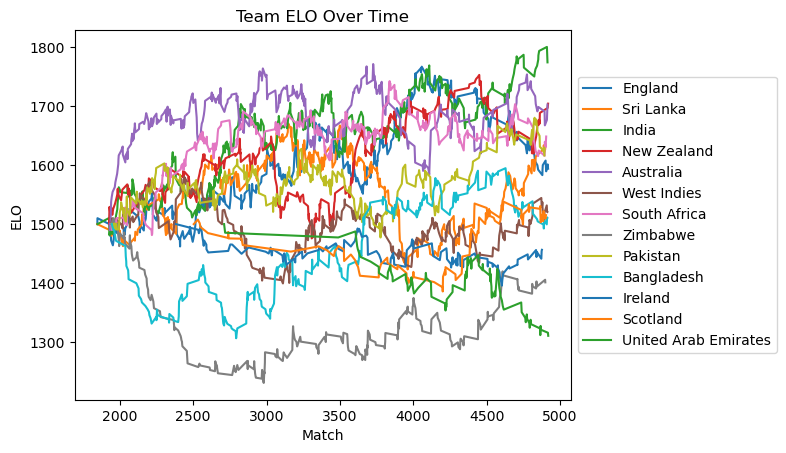

In [16]:
#plotting all team elos over time 
plt.figure()
for team, elos in team_elo_dict.items():
    if len(elos) > 100: #only plot teams with more than 100 matches for clarity
        plt.plot([x for x in elos.keys()], [x for x in elos.values()], label=team)
plt.xlabel("Match")
plt.ylabel("ELO")
plt.title("Team ELO Over Time")
#moving legend to side of chart
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

## Dataframe Generation

Including base feature creation and momentum feature engineering

In [ ]:
#inbat_bf() - calculates balls faced so far by current batsmen
def inbat_bf(df):

    # Cumulative balls faced by each batter
    df["Cum Balls Faced"] = df.groupby("Batter").cumcount() + 1

    # Last ball of each over
    over_end = df.groupby("Over").agg({
        "Batter": "last",
        "Non-Striker": "last"
    })

    # Balls faced by striker at end of over
    over_end["Batter Balls"] = (
        over_end.reset_index()
        .apply(
            lambda x: df.loc[
                (df["Over"] == x["Over"]) &
                (df["Batter"] == x["Batter"]),
                "Cum Balls Faced"
            ].iloc[-1],
            axis=1
        )
        .values
    )

    # Balls faced by non-striker at end of over
    over_end["Non-Striker Balls"] = (
        over_end.reset_index()
        .apply(
            lambda x: df.loc[
                (df["Over"] <= x["Over"]) &
                (df["Batter"] == x["Non-Striker"]),
                "Cum Balls Faced"
            ].max(),
            axis=1
        )
        .fillna(0)
        .astype(int)
    )

    # Total balls faced by the two not-out batters
    over_end["Current Bat BFs"] = (
        over_end["Batter Balls"] +
        over_end["Non-Striker Balls"]
    )

    return over_end["Current Bat BFs"]

In [ ]:
#creating dataframes for first innings and second innings data (~4 mins)
set_dict = {}
chase_dict = {}
for match in all_matches.values():
    match_id = match.match_id
    for inn in range(1,match.number_of_innings +1):
        df = match.test_df[inn]
        year = int(match.unpack_match_info()[0])
        over_df = df.groupby("Over").agg({"Cumulative Wickets" : "max", "Cumulative Runs" : "max"})
        over_df["Year"] = year

        #momentum features
        #runrate in last 5 overs
        over_df["RR Momentum"] = (
            over_df["Cumulative Runs"]
            - over_df["Cumulative Runs"].shift(5).fillna(0)
        ) / 5

        #wickets (per over) in last 5 overs
        over_df["Wx Momentum"] = (
            over_df["Cumulative Wickets"]
            - over_df["Cumulative Wickets"].shift(5).fillna(0)
        ) / 5

        #balls faced by current batsmen (after each over) feature = currently very time consuming (~4 mins)
        over_df["InBat BF"] = inbat_bf(df)

        teams = match.match_info.get("teams")
        batting_team = match.innings_teams[inn]
        bowling_team = teams[0] if teams[1] == batting_team else teams[1]
        over_df["Batting Team"] = batting_team
        over_df["Bowling Team"] = bowling_team

        #adding ELO Diff Feature
        batting_elo = team_elo_dict[batting_team][match_id]
        bowling_elo = team_elo_dict[bowling_team][match_id]
        elo_diff = batting_elo - bowling_elo
        over_df["ELO Diff"] = elo_diff

        #adding venue features
        venue_factors = matchwise_venue_df[matchwise_venue_df["Match ID"] == match_id]
        over_df["venue_set"] = venue_factors["bayes_avg_set_score"].values[0]
        over_df["venue_chase_winpct"] = venue_factors["bayes_chase_winpct"].values[0]
        over_df["venue_chase_delta"] = venue_factors["set_winavg_delta"].values[0]

        winner = match.match_info.get("outcome").get("winner","NA")
        if winner == batting_team:
            outcome = 1
        elif winner == bowling_team:
            outcome = 0
        else:
            outcome = 0.5
        over_df["Outcome"] = outcome
        
        if inn == 1:
            if over_df["Cumulative Wickets"].max() < 10 and over_df.index.max() < 50:
                #final_score = ADJUSTED
                final_score = df.iloc[-1]["Cumulative Runs"]
            else:
                final_score = df.iloc[-1]["Cumulative Runs"]

                over_df["Final Score"] = final_score
                set_dict[match_id] = (year, over_df)
                #!!!! currently only including first innings that last full 50 overs or all 10 wickets

        if inn == 2 and outcome != 0.5: #currently excluding ties / no-results
            
            target = match.ballbyball_json[2].get("target",{}).get("runs",0)
            target_overs = match.ballbyball_json[2].get("target",{}).get("overs",50)
            over_df["Req RR"] = ((target - over_df["Cumulative Runs"]) / (50 - over_df.index+0.001)).round(2)

            chase_dict[match_id] = (year, over_df)

### Generating train & test sets

In [159]:
#generating & cleaning (dtypes) random train and test sets for both models
ids = list(set_dict.keys())
rand_train_ids, rand_test_ids = train_test_split(ids, test_size=0.2, random_state=42)
rand_train_set = pd.concat([set_dict[i][1] for i in rand_train_ids]).reset_index()
rand_test_set = pd.concat([set_dict[i][1] for i in rand_test_ids]).reset_index()

rand_train_chase = pd.concat([chase_dict[i][1] for i in rand_train_ids if i in chase_dict]).reset_index()
rand_test_chase = pd.concat([chase_dict[i][1] for i in rand_test_ids if i in chase_dict]).reset_index()

rand_train_set = rand_train_set.astype({"Cumulative Runs": int, "RR Momentum": float})
rand_test_set = rand_test_set.astype({"Cumulative Runs": int, "RR Momentum": float})

rand_train_chase = rand_train_chase.astype({"Cumulative Runs": int, "Req RR": float, "Batting Team": 'category', "Bowling Team": 'category', "RR Momentum": float})
rand_test_chase = rand_test_chase.astype({"Cumulative Runs": int, "Req RR": float, "Batting Team": 'category', "Bowling Team": 'category', "RR Momentum": float})

In [160]:
#generating & cleaning (dtypes) chronological train and test sets for both models

#counting number of matches per year
set_dict_year_counts = {}
for match_id, (year, df) in set_dict.items():
    if year not in set_dict_year_counts:
        set_dict_year_counts[year] = 0
    set_dict_year_counts[year] += 1

#years till 70% of matches have trained model
total_matches = len(set_dict)
cumulative_matches = 0
for year, count in sorted(set_dict_year_counts.items()):
    cumulative_matches += count
    if cumulative_matches / total_matches >= 0.75:
        #print(f"Cutoff Year: {year}, Cumulative Matches: {cumulative_matches}, Percentage: {cumulative_matches/total_matches:.2%}")
        chrono_year_cutoff = year
        break
#chronological split of train and test sets based on year cutoff
train_ids = []
test_ids = []
for match_id, (year, df) in set_dict.items():
    if year <= chrono_year_cutoff:
        train_ids.append(match_id)
    else:
        test_ids.append(match_id)

chrono_train_set = pd.concat([set_dict[i][1] for i in train_ids]).reset_index()
chrono_test_set = pd.concat([set_dict[i][1] for i in test_ids]).reset_index()

chrono_train_set = chrono_train_set.astype({"Cumulative Runs": int, "RR Momentum": float})
chrono_test_set = chrono_test_set.astype({"Cumulative Runs": int, "RR Momentum": float})

chrono_train_chase = pd.concat([chase_dict[i][1] for i in train_ids if i in chase_dict]).reset_index()
chrono_test_chase = pd.concat([chase_dict[i][1] for i in test_ids if i in chase_dict]).reset_index()

chrono_train_chase = chrono_train_chase.astype({"Cumulative Runs": int, "Req RR": float, "Batting Team": 'category', "Bowling Team": 'category', "RR Momentum": float})
chrono_test_chase = chrono_test_chase.astype({"Cumulative Runs": int, "Req RR": float, "Batting Team": 'category', "Bowling Team": 'category', "RR Momentum": float})

### Defining model-build functions and custom metrics functions

Model Architecture:

Both models use **XGBoost** with the `hist` tree method for efficiency on 
tabular sports data. A model can be trained under two train/test split regimes:

- **Random split** — 80/20 stratified randomly. Useful as an upper-bound benchmark.
- **Chronological split** — trained on older matches, tested on recent matches. 
  More realistic for deployment; avoids temporal leakage.

A custom metrics suite is applied to each run, covering feature importances, 
permutation importances, and phase-by-phase error analysis.

In [32]:
#set_model() - 1st innings XGBoost model function 
from sklearn.metrics import mean_absolute_error, mean_squared_error
def set_model(add_features = [], split = "rand", model_type = "xgb", set_target = "Final Score", printbool = False):
    set_base_features = ["Over","Cumulative Wickets", "Cumulative Runs"]

    if split == "rand":
        train_set = rand_train_set
        test_set = rand_test_set
        split_name = "random"
    elif split == "chrono":
        train_set = chrono_train_set
        test_set = chrono_test_set
        split_name = "chronological"
    else:
        raise ValueError("Invalid split type. Use 'rand' or 'chrono'.")
    
    options = train_set.columns.drop(set_base_features).drop(set_target)
    if add_features == "options":
        print(options)
        return
    if all(x in options for x in add_features):
        feature_cols = set_base_features + add_features
    else:
        raise ValueError(f"Invalid features added - current options: {options}")

    X_train = train_set[feature_cols]
    y_train = train_set[set_target]
    X_test = test_set[feature_cols]
    y_test = test_set[set_target]

    if model_type == "xgb":
        model = xgb.XGBRegressor(tree_method="hist")
    
    model.fit(X_train, y_train)
    if printbool:
        if add_features == []:
            print(f"Model trained with {split_name} split and base features.")
        else:
            print(f"Model trained with {split_name} split and base features + {add_features}.")
        print()
        reg_custom_metrics(model, (X_test, y_test))

    mae = mean_absolute_error(y_test, model.predict(X_test))
    mse = mean_squared_error(y_test, model.predict(X_test))
    rmse = mse ** 0.5
    return model, mae, rmse

In [26]:
#reg_custom_metrics() - custom metrics function for regression model evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error
from matplotlib import pyplot as plt
def reg_custom_metrics(model, test_data):  
    (X_test, y_test) = test_data
    #score_predictor_xgb.feature_importances_
    print("Feature Importances:")
    for i, importance in enumerate(model.feature_importances_):
        print(f"{X_test.columns[i]}: {importance:.2f}")
    print()
    #permutation importance
    perm_importance = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)
    print("Permutation Importances:")
    for i in perm_importance.importances_mean.argsort()[::-1]:
        print(f"{X_test.columns[i]}: {perm_importance.importances_mean[i]:.2f}")

    #Calculate R^2 Score
    print()
    r2_score = model.score(X_test, y_test)
    print(f"R^2 Score: {round(r2_score,2)}")
    # Calculate Mean Absolute Error
    mae = mean_absolute_error(y_test, model.predict(X_test))
    print(f"Mean Absolute Error: {round(mae,2)}")
    
    # Calculate Mean Squared Error
    mse = mean_squared_error(y_test, model.predict(X_test))
    rmse = mse ** 0.5
    norm_rmse = rmse / (y_test.max() - y_test.min())
    #print(f"Mean Squared Error: {round(mse,2)}")
    print(f"Normalized Root Mean Squared Error: {round(norm_rmse,2)}")
    print()
    
    mae_per_phase = X_test.groupby((X_test["Over"]-1 )// 10).apply(lambda group: mean_absolute_error(y_test[group.index], model.predict(X_test.iloc[group.index]))).round(2)
    #phase_labels = [f"{i*10+1}-{(i+1)*10}" for i in range(5)]
    mae_per_phase.index = [1,2,3,4,5]
    print("Mean Absolute Error by Match Phase:")
    print(mae_per_phase)#.reset_index(name="MAE").rename(columns={"index":"Phase"}))

    residuals = y_test - model.predict(X_test)
    #plt.scatter(model.predict(X_test), residuals)
    #histogram of residuals
    plt.figure()
    plt.hist(residuals, bins=20)
    plt.title("Histogram of Residuals")
    plt.xlabel("Residuals")
    plt.ylabel("Frequency")
    plt.show()

In [33]:
#chase_model() - 2nd innings XGBoost model function
from sklearn.metrics import roc_auc_score, log_loss, brier_score_loss
def chase_model(add_features = [], split = "rand", model_type = "xgb", printbool = False):
    chase_base_features = ["Over","Cumulative Wickets", "Cumulative Runs", "Req RR"]
    chase_target = "Outcome"

    if split == "rand":
        train_set = rand_train_chase
        test_set = rand_test_chase
        split_name = "random"
    elif split == "chrono":
        train_set = chrono_train_chase
        test_set = chrono_test_chase
        split_name = "chronological"
    else:
        raise ValueError("Invalid split type. Use 'rand' or 'chrono'.")
    
    options = train_set.columns.drop(chase_base_features).drop(chase_target)
    if add_features == "options":
        print(options)
        return
    if all(x in options for x in add_features):
        feature_cols = chase_base_features + add_features
    else:
        raise ValueError(f"Invalid features added - current options: {options}")

    
    X_train = train_set[feature_cols]
    y_train = train_set[chase_target]
    X_test = test_set[feature_cols]
    y_test = test_set[chase_target]

    if model_type == "xgb":
        model = xgb.XGBClassifier(tree_method="hist", enable_categorical = True)
    else:
        raise ValueError(f"{model_type} model_type not yet supported")
    
    model.fit(X_train, y_train)
    if printbool:
        if add_features == []:
            print(f"Model trained with {split_name} split and base features.")
        else:
            print(f"Model trained with {split_name} split and base features + {add_features}.")
        print()

        class_custom_metrics(model, (X_test, y_test))

    y_pred_proba = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_pred_proba)
    brier = brier_score_loss(y_test, y_pred_proba)
    ll = log_loss(y_test, y_pred_proba)
    return model, auc, brier, ll

In [27]:
#class_custom_metrics() - custom metrics function for classification model evaluation
from sklearn.metrics import accuracy_score, roc_auc_score, log_loss, brier_score_loss
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance
def class_custom_metrics(model, test_data):
    (X_test, y_test) = test_data
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    print("Feature Importances:")
    for i, importance in enumerate(model.feature_importances_):
        print(f"{X_test.columns[i]}: {importance:.2f}")
    print()
    acc = accuracy_score(y_test, y_pred)
    #permutation importance
    perm_importance = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)
    print("Permutation Importances:")
    for i in perm_importance.importances_mean.argsort()[::-1]:
        print(f"{X_test.columns[i]}: {perm_importance.importances_mean[i]:.2f}")

    print()
    print(f"Accuracy: {round(acc,2)}")
    auc = roc_auc_score(y_test, y_pred_proba)
    print(f"AUC-ROC: {round(auc,2)}")
    ll = log_loss(y_test, y_pred_proba)
    print(f"Log Loss: {round(ll,2)}")
    brier = brier_score_loss(y_test, y_pred_proba)
    print(f"Brier Score Loss: {round(brier,2)}")
    print()
    #auc & logloss per phase
    auc_per_phase = X_test.groupby((X_test["Over"]-1 )// 10).apply(lambda group: roc_auc_score(y_test[group.index], model.predict_proba(X_test.iloc[group.index])[:, 1])).round(2)
    phase_labels = [f"{i*10+1}-{(i+1)*10}" for i in range(5)]
    auc_per_phase.index = phase_labels
    print("AUC-ROC by Match Phase:")
    print(auc_per_phase.reset_index(name="AUC-ROC").rename(columns={"index":"Phase"}))

    prob_true, prob_pred = calibration_curve(y_test, y_pred_proba, n_bins=20)
    plt.figure()
    plt.plot(prob_pred, prob_true, "s-", label="Model")
    plt.plot([0, 1], [0, 1], "k-", label="Perfectly Calibrated")
    plt.xlabel("Mean Predicted Probability")
    plt.ylabel("Fraction of Positives")
    plt.title("Calibration Plot")
    plt.legend()
    plt.show()

### Comparing random and chronological splits

## Model Performance — Base Features

Both models are trained on base in-match state features only:
**1st innings:** `Over`, `Cumulative Wickets`, `Cumulative Runs`
**2nd innings:** `Over`, `Cumulative Wickets`, `Cumulative Runs`, `Required Run Rate`

Performance is evaluated under two train/test split regimes:
- **Random split** — 80/20 stratified randomly; an optimistic upper bound
- **Chronological split** — trained on older matches, tested on recent matches; the realistic deployment estimate


In [152]:
#calculating model variation with each split regime
base_set_feats   = ["Over", "Cumulative Wickets", "Cumulative Runs"]
base_chase_feats = ["Over", "Cumulative Wickets", "Cumulative Runs", "Req RR"]

results = {}

for split in ["chrono", "random"]:
    # --- 1st innings ---
    train = chrono_train_set if split == "chrono" else rand_train_set
    test  = chrono_test_set  if split == "chrono" else rand_test_set

    m = xgb.XGBRegressor(tree_method="hist")
    m.fit(train[base_set_feats], train["Final Score"])
    preds = m.predict(test[base_set_feats])
    results[f"set_{split}"] = {
        "MAE":  round(mean_absolute_error(test["Final Score"], preds), 2),
        "RMSE": round(mean_squared_error(test["Final Score"], preds) ** 0.5, 2),
    }

    # --- 2nd innings ---
    train = chrono_train_chase if split == "chrono" else rand_train_chase
    test  = chrono_test_chase  if split == "chrono" else rand_test_chase

    m = xgb.XGBClassifier(tree_method="hist", enable_categorical=True)
    m.fit(train[base_chase_feats], train["Outcome"])
    proba = m.predict_proba(test[base_chase_feats])[:, 1]
    results[f"chase_{split}"] = {
        "AUC":   round(roc_auc_score(test["Outcome"], proba), 4),
        "Brier": round(brier_score_loss(test["Outcome"], proba), 4),
        "LL":    round(log_loss(test["Outcome"], proba), 4),
    }

# --- Pretty print ---
print("=" * 55)
print("  1ST INNINGS — Score Predictor (Base Features)")
print("=" * 55)
print(f"  {'Metric':<12} {'Random Split':>14} {'Chrono Split':>14}")
print("-" * 55)
for metric in ["MAE", "RMSE"]:
    r = results[f"set_random"][metric]
    c = results[f"set_chrono"][metric]
    flag = "⚠️ " if abs(c - r) / r > 0.05 else "  "
    print(f"  {metric:<12} {r:>14} {c:>13} {flag}")

print()
print("=" * 55)
print("  2ND INNINGS — Chase Predictor (Base Features)")
print("=" * 55)
print(f"  {'Metric':<12} {'Random Split':>14} {'Chrono Split':>14}")
print("-" * 55)
for metric in ["AUC", "Brier", "LL"]:
    r = results[f"chase_random"][metric]
    c = results[f"chase_chrono"][metric]
    # for AUC higher is better; for Brier/LL lower is better
    gap = (r - c) / r if metric == "AUC" else (c - r) / r
    flag = "⚠️ " if gap > 0.05 else "  "
    print(f"  {metric:<12} {r:>14} {c:>13} {flag}")

print()
print(f"  ⚠️  = >5% degradation on chronological split")

  1ST INNINGS — Score Predictor (Base Features)
  Metric         Random Split   Chrono Split
-------------------------------------------------------
  MAE                   28.86         32.29 ⚠️ 
  RMSE                  40.36         44.65 ⚠️ 

  2ND INNINGS — Chase Predictor (Base Features)
  Metric         Random Split   Chrono Split
-------------------------------------------------------
  AUC                   0.905        0.8892   
  Brier                0.1257        0.1386 ⚠️ 
  LL                   0.3889        0.4345 ⚠️ 

  ⚠️  = >5% degradation on chronological split



### 1st Innings — Score Predictor

| Metric | Random Split | Chrono Split | Δ |
|--------|-------------|-------------|---|
| MAE | 28.86 | 32.29 | +3.43 (+11.9%) |
| RMSE | 40.36 | 44.65 | +4.29 (+10.6%) |

On a random split, the model predicts final innings score to within **~29 runs** on average. Under a chronological split this rises to **~32 runs** — an 11.9% degradation, indicating mild but meaningful temporal drift. 

---

### 2nd Innings — Chase Predictor

| Metric | Random Split | Chrono Split | Δ |
|--------|-------------|-------------|---|
| AUC-ROC | 0.9050 | 0.8892 | −0.0158 (−1.7%) |
| Brier Score | 0.1257 | 0.1386 | +0.0129 (+10.3%) |
| Log Loss | 0.3889 | 0.4345 | +0.0456 (+11.7%) |

The chase model is the stronger of the two. An AUC of **0.889 on the chronological split** means the model correctly ranks the chasing team's win probability above a random baseline 89% of the time — using only live match state with no pre-match information. The AUC gap between splits is small (1.7%), suggesting the ranking signal is robust over time. The larger degradation in Brier score and log loss (both ~11%) reflects reduced probability calibration on recent matches — the model's confidence is slightly less reliable than its ranking ability.

---

### Interpreting the Split Gap

The consistent ~11% degradation across metrics on the chronological split is expected and healthy — it rules out severe temporal leakage while confirming the models generalise to unseen future matches. The chronological figures are the ones used throughout this analysis as the honest estimate of real-world performance.

## 1st Innings Predictor Models

In [165]:
#feature ablation for set model
set_ablation_configs = [
    ("Base",                    []),
    ("+ Year",                  ["Year"]),
    ("+ ELO Diff",              ["ELO Diff"]),
    ("+ Venue Set Score",       ["venue_set"]),
    ("+ RR Momentum",           ["RR Momentum"]),
    ("+ Wx Momentum",           ["Wx Momentum"]),
    ("+ InBat BF",              ["InBat BF"]),
]

#print("Running 1st innings ablation (chrono split)...")
set_rows = []
base_mae = None
for label, feats in set_ablation_configs:
    model, mae, rmse = set_model(feats, split="chrono")
    if base_mae is None:
        base_mae = mae
    delta = mae - base_mae
    set_rows.append({
        "Feature Set":   label,
        "MAE":           round(mae, 2),
        "RMSE":          round(rmse, 2),
        "ΔMAE vs Base":  f"{delta:+.2f}",
    })
    #print(f"  {label:<30} MAE={mae:.2f}  ΔMAE={delta:+.2f}")

Model trained with chronological split and base features.

Feature Importances:
Over: 0.10
Cumulative Wickets: 0.60
Cumulative Runs: 0.29

Permutation Importances:
Cumulative Runs: 3.10
Over: 2.21
Cumulative Wickets: 0.81

R^2 Score: 0.57
Mean Absolute Error: 32.29
Normalized Root Mean Squared Error: 0.1

Mean Absolute Error by Match Phase:
1    51.18
2    41.48
3    31.26
4    22.10
5    10.76
dtype: float64


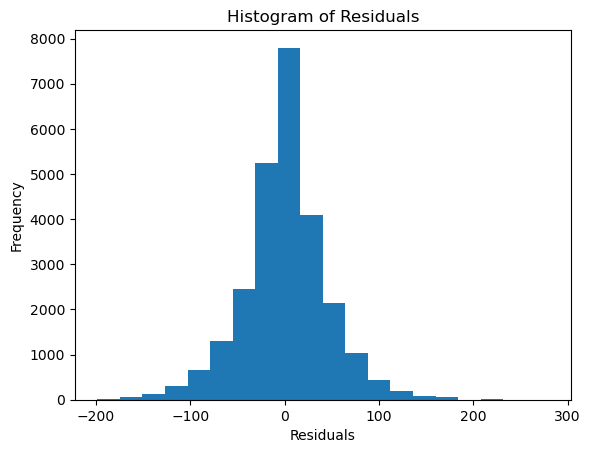

In [153]:
#Base Set Model with chronological split
set_base = set_model(split = "chrono", printbool = True)

In [167]:
#Set Feature Ablation Summary Presentation
set_ablation_df   = pd.DataFrame(set_rows)

def highlight_best(df, metric_col, lower_is_better=True):
    """Bold the best row for a given metric."""
    best_idx = df[metric_col].idxmin() if lower_is_better else df[metric_col].idxmax()
    styled = df.style.apply(
        lambda row: ["font-weight: bold" if row.name == best_idx else "" for _ in row],
        axis=1
    )
    return styled

print("\n" + "="*60)
print("1ST INNINGS — Score Predictor Ablation (Chronological Split)")
print("="*60)
display(
    highlight_best(set_ablation_df, "MAE", lower_is_better=True)
    .set_caption("Lower MAE = better. Bold = best feature set.")
    .set_table_styles([{"selector": "caption", "props": [("font-size", "0.9em"), ("color", "#555")]}])
    .hide(axis="index")
)


1ST INNINGS — Score Predictor Ablation (Chronological Split)


Feature Set,MAE,RMSE,ΔMAE vs Base
Base,32.290000,44.650000,+0.00
+ Year,34.050000,47.030000,+1.76
+ ELO Diff,33.300000,45.400000,+1.01
+ Venue Set Score,33.030000,45.870000,+0.74
+ RR Momentum,32.480000,44.810000,+0.19
+ Wx Momentum,32.350000,44.710000,+0.06
+ InBat BF,32.400000,44.840000,+0.11


## 2nd Innings Predictor Models

Model trained with chronological split and base features.

Feature Importances:
Over: 0.07
Cumulative Wickets: 0.21
Cumulative Runs: 0.13
Req RR: 0.59

Permutation Importances:
Req RR: 0.21
Cumulative Wickets: 0.10
Cumulative Runs: 0.05
Over: 0.04

Accuracy: 0.8
AUC-ROC: 0.89
Log Loss: 0.43
Brier Score Loss: 0.14

AUC-ROC by Match Phase:
   Phase  AUC-ROC
0   1-10     0.82
1  11-20     0.86
2  21-30     0.90
3  31-40     0.93
4  41-50     0.96


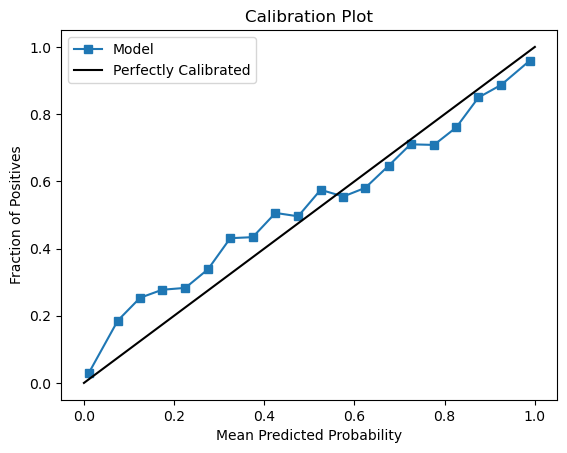

In [156]:
#Base Chase Model with chronological split
chase_base = chase_model(split = "chrono", printbool = True)

In [169]:
#feature ablation for chase model
chase_ablation_configs = [
    ("Base",                        []),
    ("+ Year",                      ["Year"]),
    ("+ ELO Diff",                  ["ELO Diff"]),
    ("+ Venue Chase Win%",          ["venue_chase_winpct"]),
    ("+ RR Momentum",               ["RR Momentum"]),
    ("+ Wx Momentum",               ["Wx Momentum"]),
    ("+ InBat BF",                  ["InBat BF"]),
]

#print("\nRunning 2nd innings ablation (chrono split)...")
chase_rows = []
base_auc = None
for label, feats in chase_ablation_configs:
    model, auc, ll, brier = chase_model(feats, split="chrono")
    if base_auc is None:
        base_auc = auc
    delta = auc - base_auc
    chase_rows.append({
        "Feature Set":    label,
        "AUC-ROC":        round(auc, 4),
        "Log Loss":       round(ll, 4),
        "Brier Score":    round(brier, 4),
        "ΔAUC vs Base":   f"{delta:+.4f}",
    })
    #print(f"  {label:<35} AUC={auc:.4f}  ΔAUC={delta:+.4f}")

In [170]:
#Chase Feature Ablation Summary Presentation
chase_ablation_df = pd.DataFrame(chase_rows)
print("\n" + "="*60)
print("2ND INNINGS — Chase Predictor Ablation (Chronological Split)")
print("="*60)
display(
    highlight_best(chase_ablation_df, "AUC-ROC", lower_is_better=False)
    .set_caption("Higher AUC = better. Bold = best feature set.")
    .set_table_styles([{"selector": "caption", "props": [("font-size", "0.9em"), ("color", "#555")]}])
    .hide(axis="index")
)


2ND INNINGS — Chase Predictor Ablation (Chronological Split)


Feature Set,AUC-ROC,Log Loss,Brier Score,ΔAUC vs Base
Base,0.889200,0.138600,0.434500,+0.0000
+ Year,0.885600,0.143900,0.474500,-0.0037
+ ELO Diff,0.881600,0.151800,0.507700,-0.0077
+ Venue Chase Win%,0.877100,0.152900,0.509000,-0.0121
+ RR Momentum,0.888100,0.139400,0.438100,-0.0012
+ Wx Momentum,0.890100,0.137900,0.433200,+0.0008
+ InBat BF,0.889300,0.138600,0.436600,+0.0001


## Key Findings

- **Chronological vs random split gap:** ~11% degradation across both models —
  indicating mild but meaningful temporal drift, with ranking ability (AUC) 
  proving more stable over time than probability calibration (Brier, Log Loss).

- **Base features dominate:** Ablation testing revealed that no individual feature
  or combination meaningfully improved on the base model under chronological 
  evaluation. The best performing addition was Wicket Momentum for the chase model 
  (+0.0008 AUC) and Wicket Momentum for the score predictor (−0.06 MAE) — both 
  negligible. Pre-match context features (ELO, Venue, Year) consistently *hurt* 
  performance, suggesting live match state overwrites pre-match signal by the time 
  meaningful predictions are made.

- **Phase analysis:** Prediction error is highest in overs 1–10 (highest variance 
  phase) and lowest in overs 41–50 (score largely set by then).

**Future work:** Isolate feature value in early overs (1–15) where pre-match 
context may add signal before live state dominates; apply SHAP explainability 
to understand which in-match features drive individual predictions; 
and build a live match dashboard for real-time visualisation.

### (ONGOING) Future Work - Over-by-Over 2nd Innings Win Probability (Presentation)

In [ ]:
# indiv_match_process(match_id) - generates set & chase over_dfs for given match
def indiv_match_process(match_id):
    match = all_matches.get(match_id, "NA")
    if match == "NA": raise ValueError(f"Match {match_id} not available")

    for inn in range(1,match.number_of_innings +1):
        df = match.test_df[inn]
        year = int(match.unpack_match_info()[0])
        over_df = df.groupby("Over").agg({"Cumulative Wickets" : "max", "Cumulative Runs" : "max"})
        over_df["Year"] = year

        #momentum features
        #runrate in last 5 overs
        over_df["RR Momentum"] = (
            over_df["Cumulative Runs"]
            - over_df["Cumulative Runs"].shift(5).fillna(0)
        ) / 5

        #wickets (per over) in last 5 overs
        over_df["Wx Momentum"] = (
            over_df["Cumulative Wickets"]
            - over_df["Cumulative Wickets"].shift(5).fillna(0)
        ) / 5

        #balls faced by current batsmen (after each over) feature = currently very time consuming (~4 mins)
        over_df["InBat BF"] = inbat_bf(df)

        teams = match.match_info.get("teams")
        batting_team = match.innings_teams[inn]
        bowling_team = teams[0] if teams[1] == batting_team else teams[1]
        over_df["Batting Team"] = batting_team
        over_df["Bowling Team"] = bowling_team

        #adding ELO Diff Feature
        batting_elo = team_elo_dict[batting_team][match_id]
        bowling_elo = team_elo_dict[bowling_team][match_id]
        elo_diff = batting_elo - bowling_elo
        over_df["ELO Diff"] = elo_diff

        #adding venue features
        venue_factors = matchwise_venue_df[matchwise_venue_df["Match ID"] == match_id]
        over_df["venue_set"] = venue_factors["bayes_avg_set_score"].values[0]
        over_df["venue_chase_winpct"] = venue_factors["bayes_chase_winpct"].values[0]
        over_df["venue_chase_delta"] = venue_factors["set_winavg_delta"].values[0]

        winner = match.match_info.get("outcome").get("winner","NA")
        if winner == batting_team:
            outcome = 1
        elif winner == bowling_team:
            outcome = 0
        else:
            outcome = 0.5
        over_df["Outcome"] = outcome
        
        if inn == 1:
            if over_df["Cumulative Wickets"].max() < 10 and over_df.index.max() < 50:
                #final_score = ADJUSTED
                final_score = df.iloc[-1]["Cumulative Runs"]
            else:
                final_score = df.iloc[-1]["Cumulative Runs"]

                over_df["Final Score"] = final_score
                set_over_df = over_df.reset_index()
                #!!!! currently only including first innings that last full 50 overs or all 10 wickets

        if inn == 2 and outcome != 0.5: #currently excluding ties / no-results
            
            target = match.ballbyball_json[2].get("target",{}).get("runs",0)
            target_overs = match.ballbyball_json[2].get("target",{}).get("overs",50)
            over_df["Req RR"] = ((target - over_df["Cumulative Runs"]) / (50 - over_df.index+0.001)).round(2)

            chase_over_df = over_df.reset_index()
    return set_over_df, chase_over_df

In [ ]:
# chase_winviz_plot(match_id) - generates progression win probability plot for given match
def chase_winviz_plot(match_id):
    chase_df = indiv_match_process(match_id)[1][["Over","Cumulative Wickets", "Cumulative Runs", "Req RR"]].copy()

    # --- Derived columns ---
    chase_df["Runs This Over"] = chase_df["Cumulative Runs"].diff().fillna(chase_df["Cumulative Runs"])
    chase_df["Wickets This Over"] = chase_df["Cumulative Wickets"].diff().fillna(chase_df["Cumulative Wickets"]).astype(int)
    chase_df["Run Rate"] = (chase_df["Cumulative Runs"] / chase_df["Over"]).round(2)

    # --- Model predictions ---
    model, auc, brier, ll = chase_model(split="chrono")
    feature_cols = ["Over", "Cumulative Wickets", "Cumulative Runs", "Req RR"]
    chase_df["Win Probability"] = model.predict_proba(chase_df[feature_cols])[:, 1]

    # --- Plot ---
    fig, ax1 = plt.subplots(figsize=(12, 5))

    # Win probability (left axis)
    ax1.plot(chase_df["Over"], chase_df["Win Probability"], color="steelblue", linewidth=2, label="Win Probability")
    ax1.set_xlabel("Over")
    ax1.set_ylabel("Win Probability", color="steelblue")
    ax1.tick_params(axis="y", labelcolor="steelblue")
    ax1.set_ylim(0, 1.05)
    #ax1.axhline(0.5, color="steelblue", linestyle="--", linewidth=0.8, alpha=0.5)

    # Run rate (right axis)
    ax2 = ax1.twinx()
    ax2.plot(chase_df["Over"], chase_df["Run Rate"], color="darkorange", linewidth=2, label="Run Rate", alpha=0.85)
    # Runs per over bars (right axis, same scale as run rate)
    ax2.bar(chase_df["Over"], chase_df["Runs This Over"], color="darkorange",
            alpha=0.2, width=0.8, label="Runs This Over")
    ax2.set_ylabel("Run Rate", color="darkorange")
    ax2.tick_params(axis="y", labelcolor="darkorange")

    # Wicket markers on run rate line — stacked vertically if multiple in one over
    for _, row in chase_df[chase_df["Wickets This Over"] > 0].iterrows():
        for w in range(int(row["Wickets This Over"])):
            offset = w * 0.3  # stack multiple wickets vertically
            ax2.plot(row["Over"], row["Run Rate"] + offset, marker="x", color="red",
                    markersize=10, markeredgewidth=2.5)

    # Legend
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    from matplotlib.lines import Line2D
    from matplotlib.patches import Patch
    wicket_marker = Line2D([0], [0], marker="x", color="red", linestyle="None",
                            markersize=9, markeredgewidth=2.5, label="Wicket")
    #runs_bar = Patch(color="darkorange", alpha=0.2, label="Runs This Over")
    ax1.legend(handles=lines1 + lines2 + [wicket_marker], loc="upper left")

    plt.title(f"Match {match_id} — Chase Win Probability & Run Rate by Over")
    plt.tight_layout()
    plt.show()

    all_matches[match_id].print_match_scorecard()

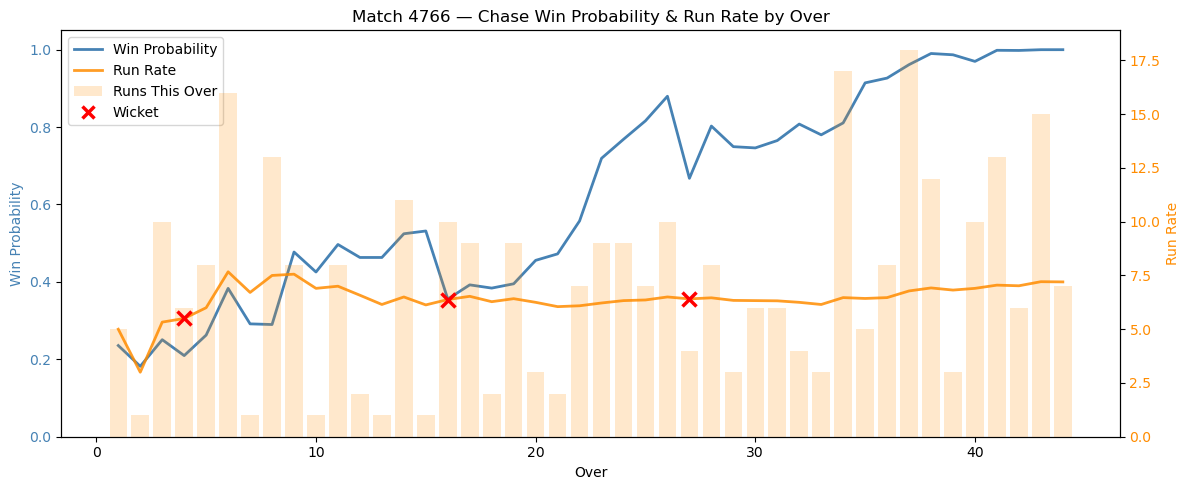

Australia tour of England - 1st Test
19 - 19 September 2024
England won the toss and elected to bat.
Australia won by 7 wickets

England
    Batting         Dismissal                            Runs    Balls    4s    6s    Strike Rate
--  --------------  ---------------------------------  ------  -------  ----  ----  -------------
 1  PD Salt         b BJ Dwarshuis                         17       24     2     0          70.83
 2  BM Duckett      c & b M Labuschagne                    95       92    11     0         103.26
 3  WG Jacks        c SPD Smith b A Zampa                  62       60     5     2         103.33
 4  HC Brook        c & b M Labuschagne                    39       31     2     3         125.81
 5  JL Smith        c sub(C Connolly) b MW Short           23       20     2     1         115.00
 6  LS Livingstone  c C Green b A Zampa                    13       17     1     0          76.47
 7  JG Bethell      c M Labuschagne b TM Head              35       35     3   

In [155]:
match_id = 4766
chase_winviz_plot(match_id)

In [162]:
#filter training sets from overs a to b (testing models in specific phases)
a = 1
b = 10
filter = list(range(a, b + 1))
ab_filter_rand_test_set = rand_test_set[rand_test_set["Over"].isin(filter)]
ab_filter_rand_test_chase = rand_test_chase[rand_test_chase["Over"].isin(filter)]
ab_filter_rand_train_set = rand_train_set[rand_train_set["Over"].isin(filter)]
ab_filter_rand_train_chase = rand_train_chase[rand_train_chase["Over"].isin(filter)]
ab_filter_chrono_test_set = chrono_test_set[chrono_test_set["Over"].isin(filter)]
ab_filter_chrono_test_chase = chrono_test_chase[chrono_test_chase["Over"].isin(filter)]
ab_filter_chrono_train_set = chrono_train_set[chrono_train_set["Over"].isin(filter)]
ab_filter_chrono_train_chase = chrono_train_chase[chrono_train_chase["Over"].isin(filter)]